In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sun Feb  8 13:46:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import os

In [ ]:
img = image.load_img('/content/drive/MyDrive/CNN (Happy NotHappy)/training/Happy/3.jpg')

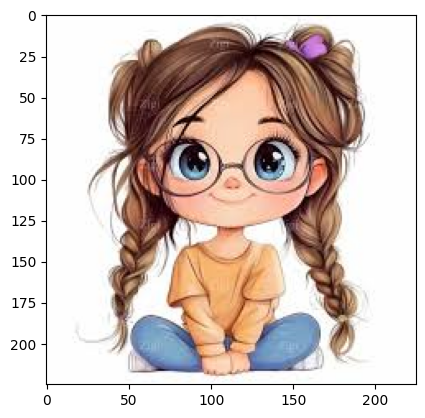

In [ ]:
plt.imshow(img)

array([[[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]]], dtype=uint8)
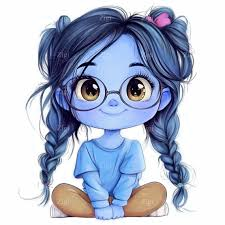

In [ ]:
i = cv2.imread('/content/drive/MyDrive/CNN (Happy NotHappy)/training/Happy/3.jpg')
i

In [ ]:
i.shape

(225, 225, 3)

In [ ]:
train = ImageDataGenerator(rescale = 1/200)
validation = ImageDataGenerator(rescale =1/200)
#test = ImageDataGenerator(rescale = 1/200)

In [ ]:
train_dataset = train.flow_from_directory('/content/drive/MyDrive/CNN (Happy NotHappy)/training',
                                          target_size = (200,200),
                                          batch_size = 32,
                                          class_mode = 'binary')
validation_dataset = validation.flow_from_directory('/content/drive/MyDrive/CNN (Happy NotHappy)/validation',
                                                    target_size = (200,200),
                                                    batch_size = 32,
                                                    class_mode = 'binary')
#testing_dataset = test.flow_from_directory('/content/drive/MyDrive/CNN (Happy NotHappy)/testing',
 #                                          target_size = (200,200),
  #                                         batch_size = 32,
    #                                       class_mode = 'binary')

Found 50 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [ ]:
train_dataset.class_indices

{'Happy': 0, 'NotHappy': 1}

In [ ]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1], dtype=int32)

In [ ]:
model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    #
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.001),
              metrics = ['accuracy']
              )

In [ ]:
model_fit = model.fit(train_dataset,
                     epochs = 10)

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9392 - loss: 0.2893
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6600 - loss: 0.6972
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 1.0000 - loss: 0.3226
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.9600 - loss: 0.2112
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5608 - loss: 0.6029
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9681 - loss: 0.3008
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.9733 - loss: 0.1599
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9525 - loss: 0.1647
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 1.0000 - loss: 0.0816
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0457


In [ ]:
dir_path ='/content/drive/MyDrive/CNN (Happy NotHappy)/testing'
for i in os.listdir(dir_path):
  print(i)

3.jpg
6.jpg
8.jpg
19.jpg
20.jpg
35.jpg
40.jpg
41.jpg
47 (1).jpg
47.jpg
49.jpg


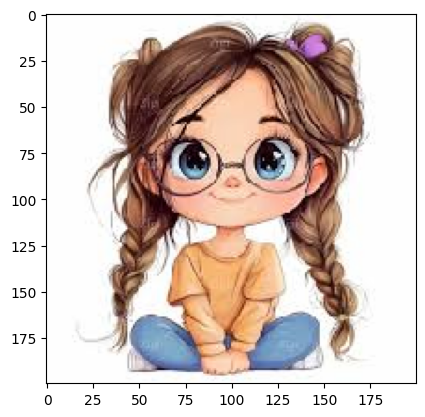

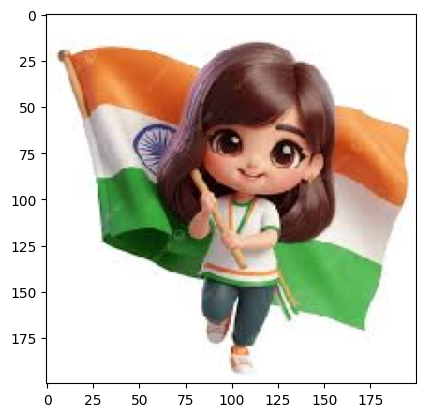

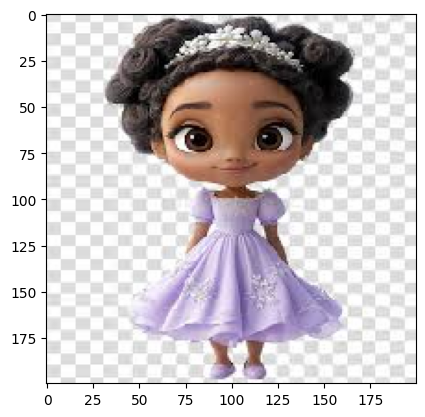

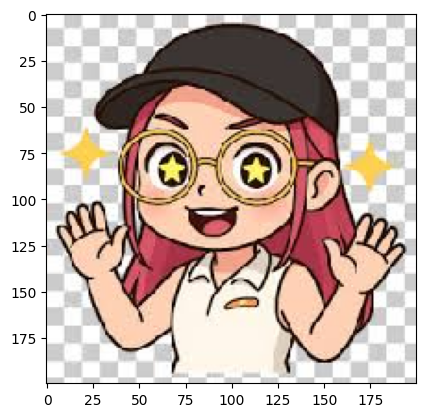

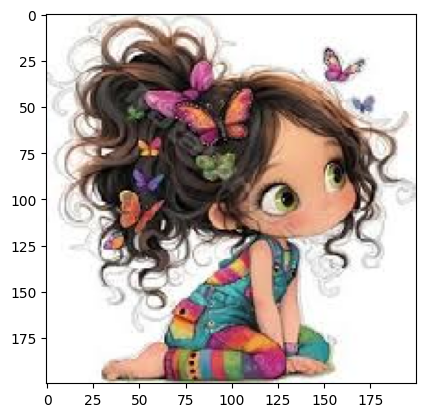

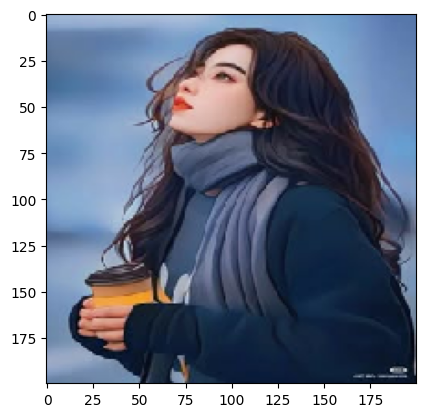

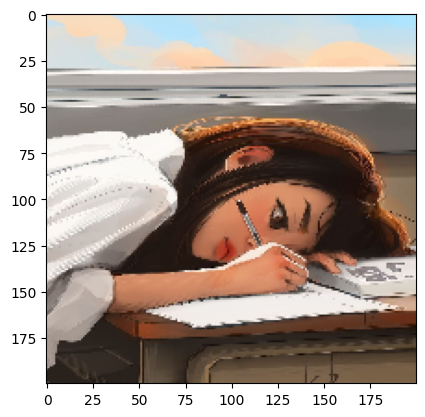

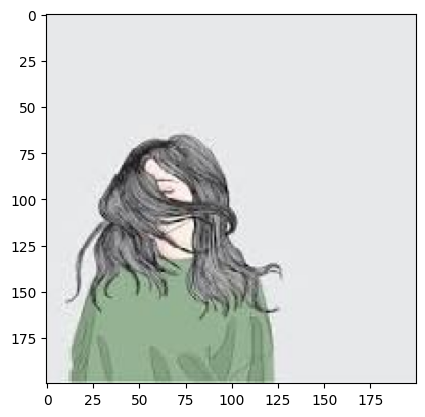

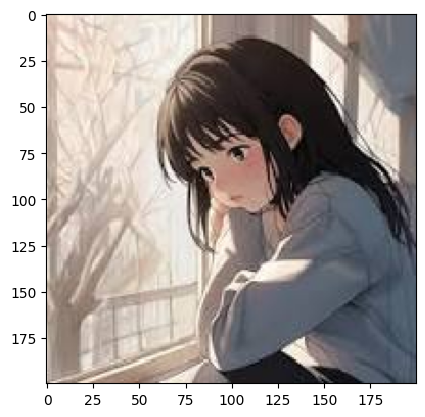

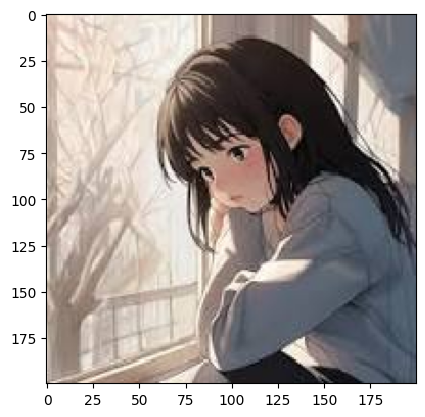

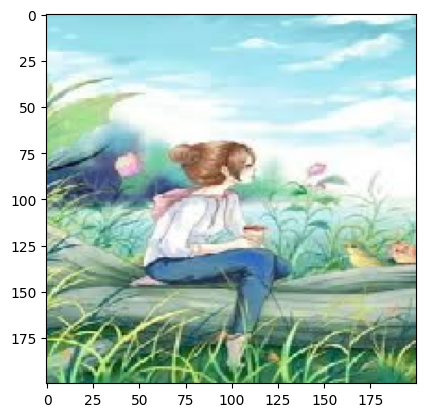

In [ ]:
dir_path = '/content/drive/MyDrive/CNN (Happy NotHappy)/testing'

for i in os.listdir(dir_path):
  img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
  plt.imshow(img)
  plt.show()

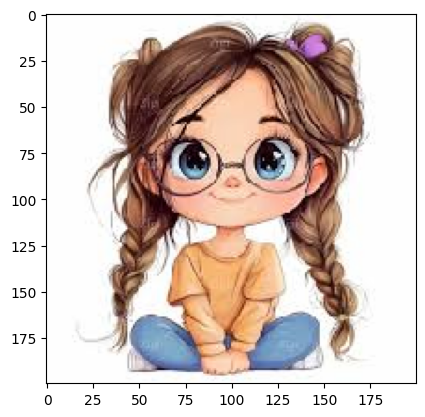

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step
Not-Happy Face


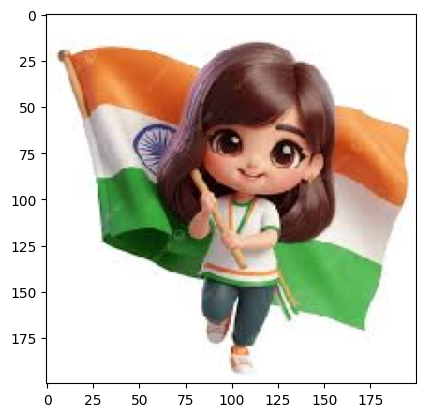

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Not-Happy Face


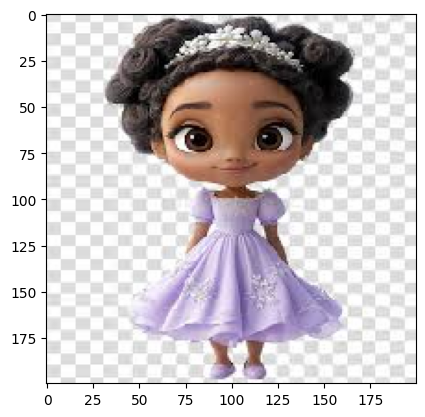

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Not-Happy Face


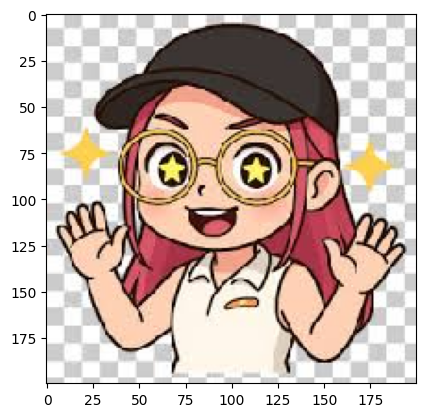

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Not-Happy Face


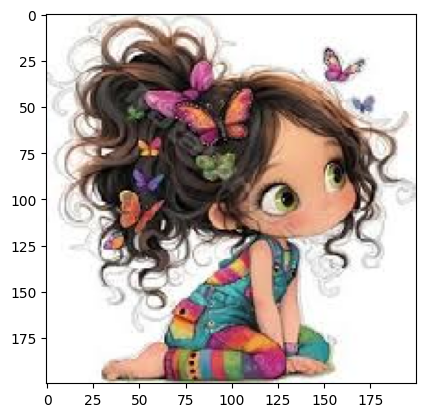

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Not-Happy Face


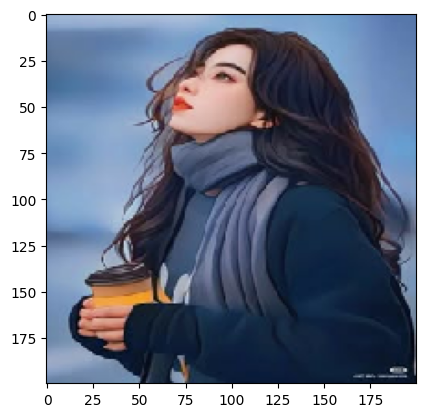

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Happy Face


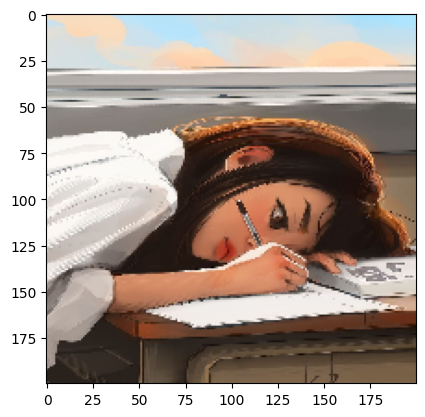

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Happy Face


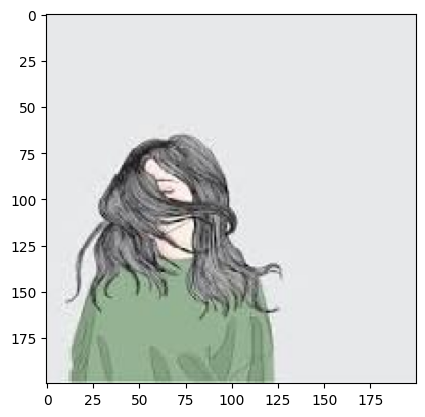

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Happy Face


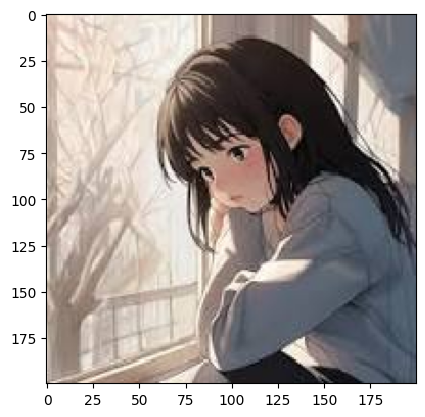

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Happy Face


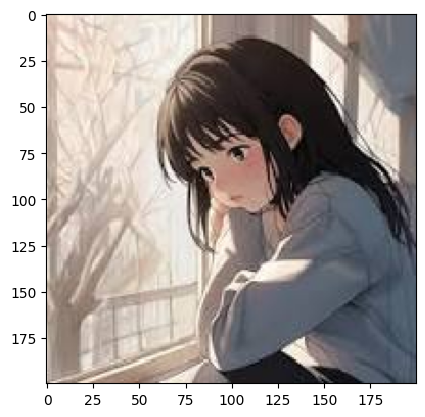

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Happy Face


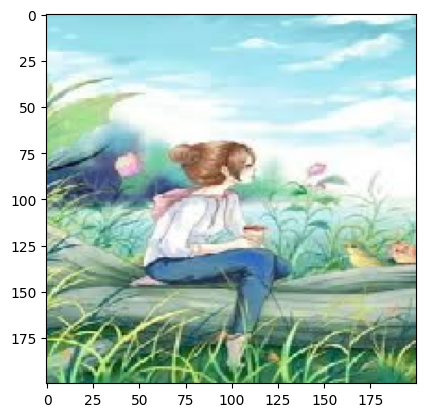

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Happy Face


In [ ]:
dir_path = '/content/drive/MyDrive/CNN (Happy NotHappy)/testing'
for i in os.listdir(dir_path ):
    img = image.load_img(dir_path+ '//'+i, target_size = (200,200))
    plt.imshow(img)
    plt.show()

    x= image.img_to_array(img)
    x=np.expand_dims(x,axis = 0)
    images = np.vstack([x])

    val = model.predict(images)
    if val == 0:
        print('Not-Happy Face')
    else:
        print('Happy Face')